# Shapash - Time Series Tabular Forecasting

This notebook illustrates tabular forecasting: lag creation, calendar features, then local and global interpretation with Shapash.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from shapash import SmartExplainer

## 1. Build a synthetic daily demand signal

In [2]:
rng = np.random.default_rng(42)
date_index = pd.date_range(start="2021-01-01", periods=900, freq="D")

trend = np.linspace(0, 25, len(date_index))
weekly = 10 * np.sin(2 * np.pi * np.arange(len(date_index)) / 7)
yearly = 20 * np.sin(2 * np.pi * np.arange(len(date_index)) / 365)
noise = rng.normal(0, 4, len(date_index))

target = 120 + trend + weekly + yearly + noise
ts_df = pd.DataFrame({"date": date_index, "target": target})
ts_df.head()

,date,target
0,2021-01-01,121.218868
1,2021-01-02,124.030454
2,2021-01-03,133.495133
3,2021-01-04,129.216916
4,2021-01-05,109.344305


## 2. Engineer tabular features (lags + calendar)

In [3]:
df = ts_df.copy()
df["lag_1"] = df["target"].shift(1)
df["lag_7"] = df["target"].shift(7)
df["rolling_mean_7"] = df["target"].shift(1).rolling(7).mean()
df["rolling_std_7"] = df["target"].shift(1).rolling(7).std()
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

model_df = df.dropna().reset_index(drop=True)
feature_cols = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "month",
    "is_weekend",
]

X = model_df[feature_cols]
y = model_df[["target"]]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
date_train = model_df["date"].iloc[:split_idx]
date_test = model_df["date"].iloc[split_idx:]

X_train.head()

,lag_1,lag_7,rolling_mean_7,rolling_std_7,day_of_week,month,is_weekend
0,114.921933,121.218868,119.875422,9.963461,4,1,0
1,121.333851,124.030454,119.891848,9.966140,5,1,1
2,130.719155,133.495133,120.847377,10.721123,6,1,1
3,129.673558,129.216916,120.301437,10.045764,0,1,0
4,131.560379,109.344305,120.636218,10.424313,1,1,0


## 3. Train and evaluate

In [4]:
model = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)
model.fit(X_train, y_train.iloc[:, 0])

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

metrics = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_train.iloc[:, 0], pred_train),
            mean_absolute_error(y_test.iloc[:, 0], pred_test),
        ],
        "R2": [
            r2_score(y_train.iloc[:, 0], pred_train),
            r2_score(y_test.iloc[:, 0], pred_test),
        ],
    },
    index=["train", "test"],
)
metrics

,MAE,R2
train,1.511569,0.985118
test,5.771074,0.535060


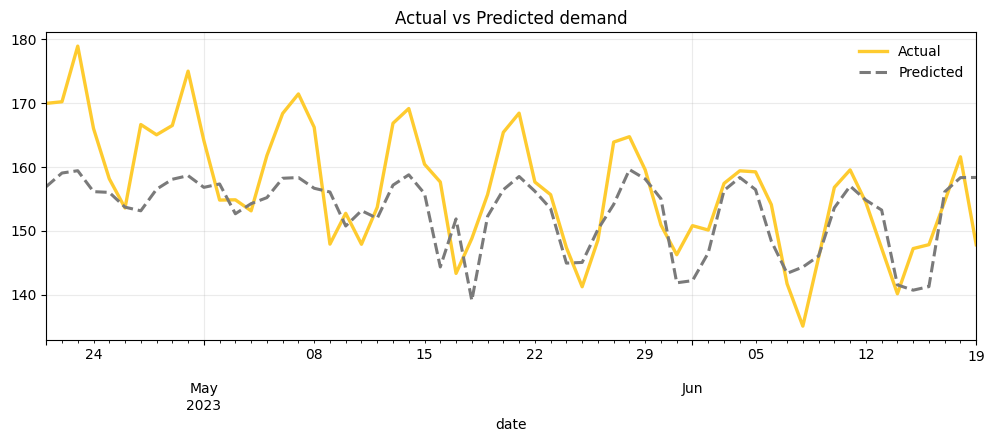

In [5]:
compare_df = pd.DataFrame(
    {
        "date": date_test.values,
        "actual": y_test.iloc[:, 0].values,
        "predicted": pred_test,
    }
)

plot_df = compare_df.set_index("date").tail(60)

ax = plot_df["actual"].plot(
    figsize=(12, 4),
    color="#FECB2F",   # jaune style Shapash
    linewidth=2.4,
    label="Actual",
)
plot_df["predicted"].plot(
    ax=ax,
    color="#7A7A7A",   # gris
    linewidth=2.2,
    linestyle="--",
    label="Predicted",
)

ax.set_title("Actual vs Predicted demand")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

## 4. Explain forecasting drivers with Shapash

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x121857410>


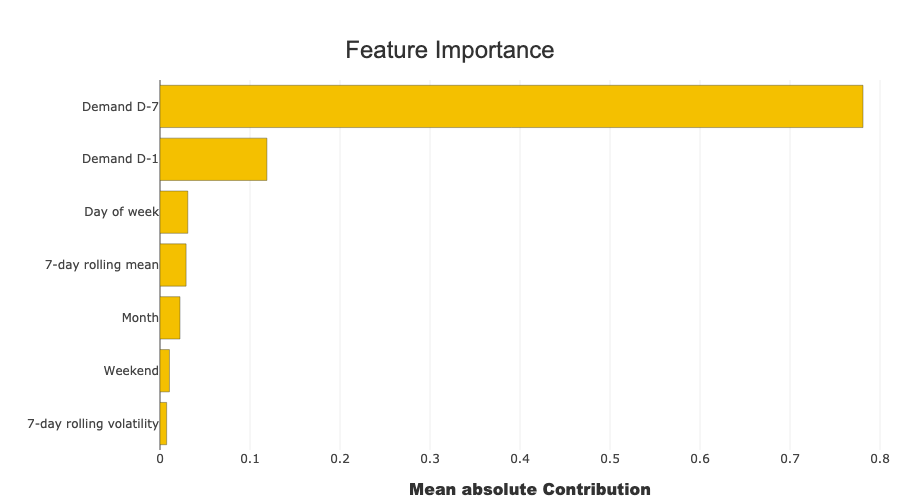

In [6]:
feature_dict = {
    "lag_1": "Demand D-1",
    "lag_7": "Demand D-7",
    "rolling_mean_7": "7-day rolling mean",
    "rolling_std_7": "7-day rolling volatility",
    "day_of_week": "Day of week",
    "month": "Month",
    "is_weekend": "Weekend",
}

xpl = SmartExplainer(
    model=model,
    features_dict=feature_dict,
    title_story="Demand forecasting with tabular features",
)

y_pred_test_df = pd.DataFrame(pred_test, columns=["target"], index=X_test.index)

xpl.compile(
    x=X_test,
    y_pred=y_pred_test_df,
    y_target=y_test,
    additional_data=model_df.loc[X_test.index, ["date"]],
)

xpl.plot.features_importance()

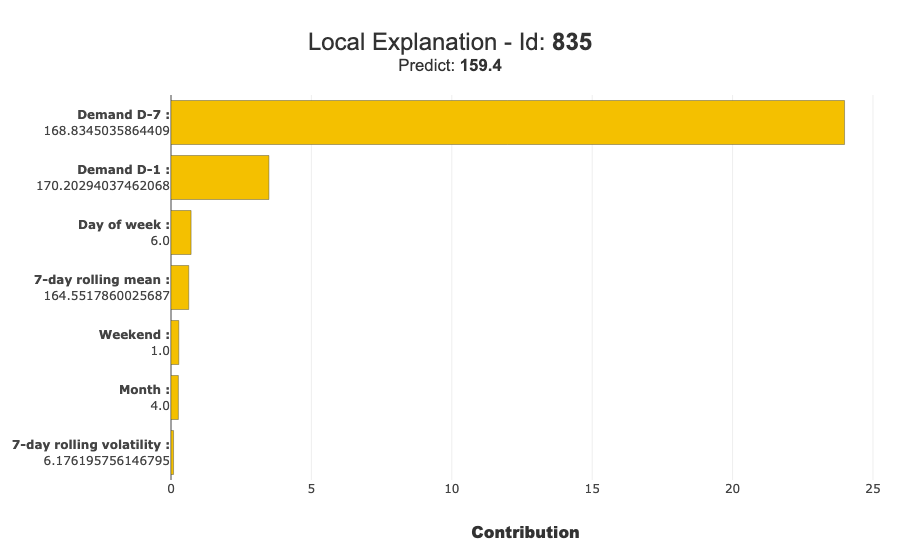

In [7]:
worst_error_idx = (y_test.iloc[:, 0] - pred_test).abs().idxmax()
xpl.plot.local_plot(index=worst_error_idx)

## 5. Leakage checklist for temporal models

- Use a strict time-based split (never random shuffling).
- Compute rolling statistics using only past values.
- Verify that calendar features are available at inference time.
- Monitor drift in lag feature distributions in production.